In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("ahmedelsany/car-brand-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 177M/177M [00:00<00:00, 200MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1):
['Car Brand Classification Dataset']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'Car Brand Classification Dataset', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'Car Brand Classification Dataset', 'test'))}")

Contents of the 'train' directory: ['BMW', 'Ford', 'INFINITI', 'Lincoln', 'Kia', 'FIAT', 'Jaguar', 'Volvo', 'Mercedes-Benz', 'Jeep', 'Chevrolet', 'Buick', 'Toyota', 'MINI', 'Honda', 'Nissan', 'Aston Martin', 'Land Rover', 'Porsche', 'Hyundai', 'Mitsubishi', 'Lexus', 'Subaru', 'Acura', 'Dodge', 'Mazda', 'Chrysler', 'Cadillac', 'GMC', 'Audi', 'Volkswagen', 'Ram', 'Bentley']
Contents of the 'test' directory: ['BMW', 'Ford', 'INFINITI', 'Lincoln', 'Kia', 'FIAT', 'Jaguar', 'Volvo', 'Mercedes-Benz', 'Jeep', 'Chevrolet', 'Buick', 'Toyota', 'MINI', 'Honda', 'Nissan', 'Aston Martin', 'Land Rover', 'Porsche', 'Hyundai', 'Mitsubishi', 'Lexus', 'Subaru', 'Acura', 'Dodge', 'Mazda', 'Chrysler', 'Cadillac', 'GMC', 'Audi', 'Volkswagen', 'Ram', 'Bentley']



--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/train) ---
Found 11517 images in /root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/train. Displaying 6 samples:


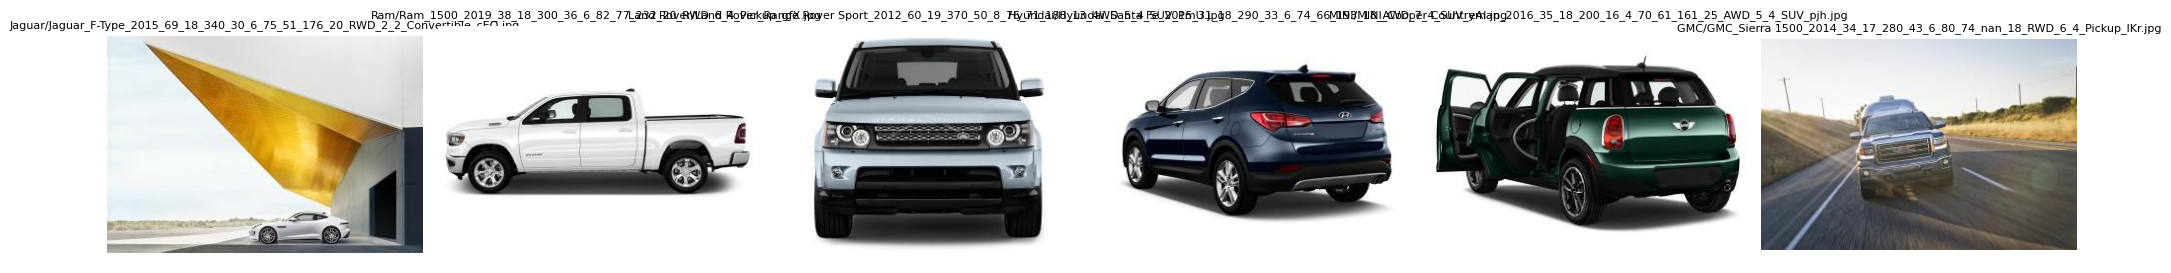


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/test) ---
Found 2475 images in /root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/test. Displaying 6 samples:


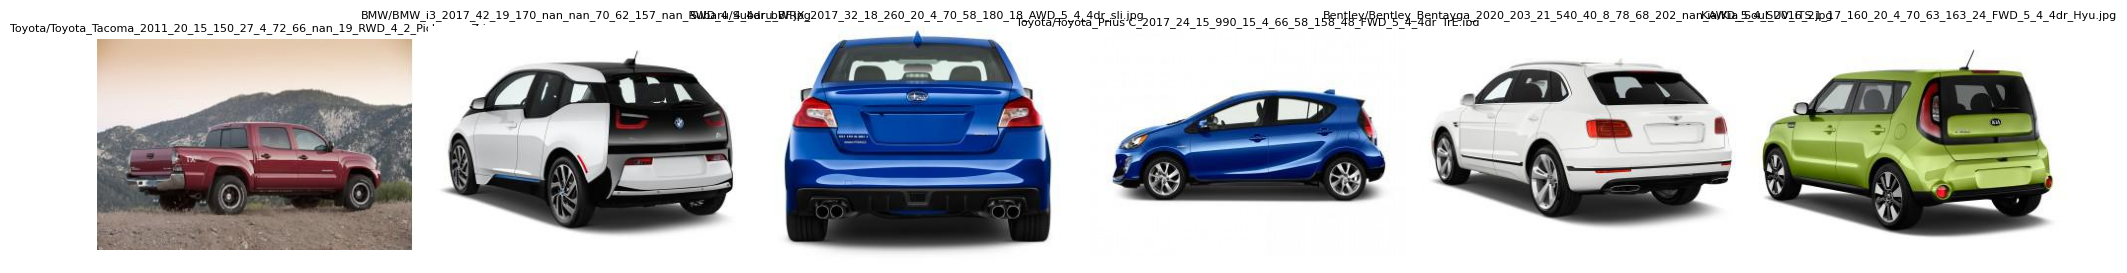

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'Car Brand Classification Dataset' subdirectory
train_path = os.path.join(path, 'Car Brand Classification Dataset', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'Car Brand Classification Dataset', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check for GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Training will proceed on CPU.')
else:
  print(f'Found GPU at: {device_name}')

# Verify physical devices
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

Found GPU at: /device:GPU:0
Num GPUs Available:  1


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Image configurations
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation and Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Build MobileNetV2 Model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base layers initially

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Found 11517 images belonging to 33 classes.
Found 2475 images belonging to 33 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 191s 477ms/step - accuracy: 0.0604 - loss: 3.4416 - val_accuracy: 0.1273 - val_loss: 3.2589
Epoch 2/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 145s 402ms/step - accuracy: 0.0995 - loss: 3.2579 - val_accuracy: 0.1547 - val_loss: 3.1069
Epoch 3/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 143s 396ms/step - accuracy: 0.1322 - loss: 3.1438 - val_accuracy: 0.1887 - val_loss: 2.9856
Epoch 4/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 143s 397ms/step - accuracy: 0.1456 - loss: 3.0752 - val_accuracy: 0.1956 - val_loss: 2.9413
Epoch 5/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 144s 401ms/step - accuracy: 0.1682 - loss: 2.9982 - val_accuracy: 0.2117 - val_loss: 2.8559
Epoch 6/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 141s 393ms/step - accuracy: 0.1783 - loss: 2.9549 - val_accuracy: 0.2210 - val_loss: 2.8101
Epoch 7/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 141s 392ms/step - accuracy: 0.17

In [ ]:
# Model Summary and Training Final Results
model.summary()

loss, accuracy = model.evaluate(test_generator)
print(f"\nFinal Test Loss: {loss:.4f}")
print(f"Final Test Accuracy: {accuracy:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         8,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,267,237 (12.46 MB)

 Trainable params: 336,417 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 672,836 (2.57 MB)

78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.2562 - loss: 2.7188

Final Test Loss: 2.7188
Final Test Accuracy: 0.2562


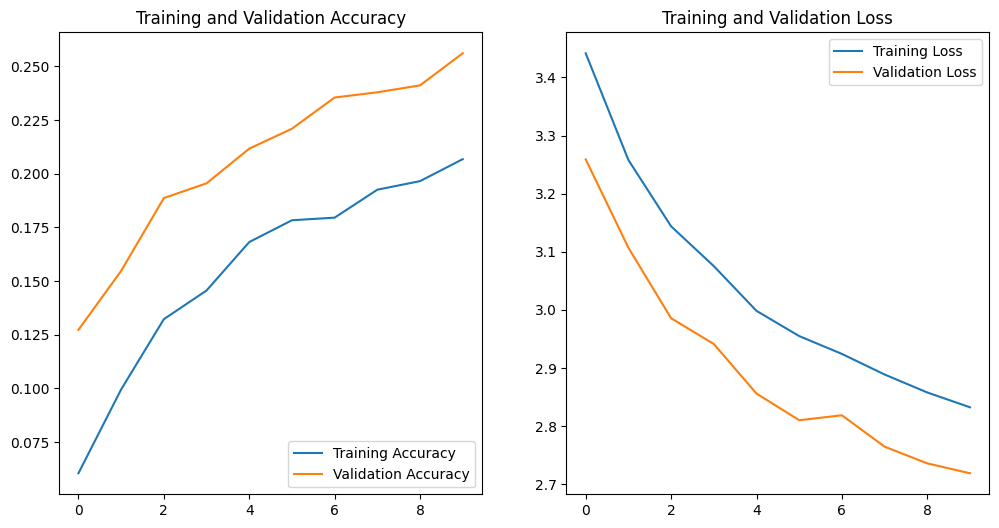

In [ ]:
import matplotlib.pyplot as plt

# Visualize training performance
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()